In [ ]:
import yfinance as yf

tickers = ["NPN.JO", "FSR.JO", "AGL.JO", "SOL.JO", "SHP.JO",
           "SPY", "QQQ", "EEM", "GLD", "TLT"]

prices = yf.download(tickers, start="2019-01-01", end="2024-12-31")["Close"]
print(prices.head())
print(prices.shape)
print(prices.isnull().sum())  # Check for missing data

[*********************100%***********************]  10 of 10 completed

Ticker            AGL.JO        EEM       FSR.JO         GLD        NPN.JO  \
Date                                                                         
2019-01-02  29982.445312  33.319084  6310.267090  121.330002  35012.968750   
2019-01-03  30041.990234  32.715004  6434.759766  122.430000  35063.253906   
2019-01-04  30232.332031  33.770046  6498.499023  121.440002  35874.148438   
2019-01-07  30413.882812  33.846622  6461.649414  121.860001  35475.617188   
2019-01-08  30585.669922  33.974243  6473.601074  121.529999  35647.601562   

Ticker             QQQ        SHP.JO        SOL.JO         SPY         TLT  
Date                                                                        
2019-01-02  148.040878  18221.871094  41682.042969  224.382507   99.445999  
2019-01-03  143.204315  18462.378906  42824.457031  219.028168  100.577644  
2019-01-04  149.331238  18761.773438  43111.058594  226.364639   99.413460  
2019-01-07  151.109055  18816.660156  42444.984375  228.149506   99.

[*********************100%***********************]  10 of 10 completed

Asset universe: 10 assets defined ✓

Download complete.
Shape: 1549 trading days × 10 assets

First 5 rows:
Missing values per asset (raw):
Ticker
AGL.JO    51
EEM       40
FSR.JO    51
GLD       40
NPN.JO    51
QQQ       40
SHP.JO    51
SOL.JO    51
SPY       40
TLT       40
dtype: int64

Total missing cells: 455
Missing values per asset (after cleaning):
Ticker
AGL.JO    0
EEM       0
FSR.JO    0
GLD       0
NPN.JO    0
QQQ       0
SHP.JO    0
SOL.JO    0
SPY       0
TLT       0
dtype: int64

Clean dataset: 1549 trading days × 10 assets
Daily returns shape: (1548, 10)

Sample statistics:
Ticker    AGL.JO       EEM    FSR.JO       GLD    NPN.JO       QQQ    SHP.JO  \
count  1548.0000 1548.0000 1548.0000 1548.0000 1548.0000 1548.0000 1548.0000   
mean      0.0007    0.0002    0.0003    0.0005    0.0009    0.0009    0.0005   
std       0.0246    0.0133    0.0201    0.0093    0.0258    0.0151    0.0193   
min      -0.1332   -0.1248   -0.1428   -0.0537   -0.1770   -0.1198   -0.1421   
25%

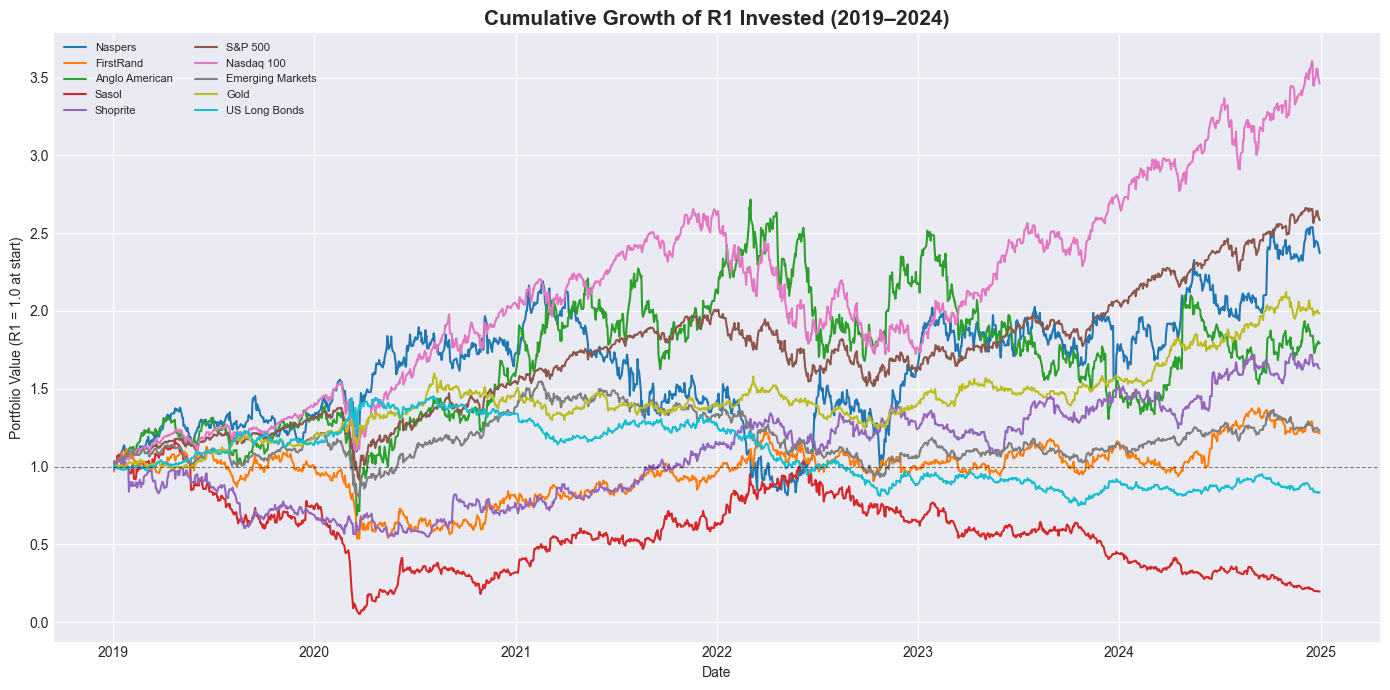

Chart saved ✓
Standard Covariance Matrix (annualised):
Ticker  AGL.JO     EEM  FSR.JO     GLD  NPN.JO     QQQ  SHP.JO  SOL.JO  \
Ticker                                                                   
AGL.JO  0.1521  0.0346  0.0376  0.0092  0.0373  0.0223  0.0163  0.1076   
EEM     0.0346  0.0445  0.0230  0.0068  0.0390  0.0369  0.0154  0.0442   
FSR.JO  0.0376  0.0230  0.1022 -0.0005  0.0168  0.0147  0.0422  0.0699   
GLD     0.0092  0.0068 -0.0005  0.0218  0.0031  0.0048 -0.0004  0.0016   
NPN.JO  0.0373  0.0390  0.0168  0.0031  0.1671  0.0253  0.0110  0.0274   
QQQ     0.0223  0.0369  0.0147  0.0048  0.0253  0.0577  0.0129  0.0322   
SHP.JO  0.0163  0.0154  0.0422 -0.0004  0.0110  0.0129  0.0938  0.0324   
SOL.JO  0.1076  0.0442  0.0699  0.0016  0.0274  0.0322  0.0324  0.4405   
SPY     0.0251  0.0314  0.0176  0.0036  0.0184  0.0438  0.0131  0.0408   
TLT    -0.0084 -0.0045 -0.0055  0.0074  0.0003 -0.0045 -0.0039 -0.0153   

Ticker     SPY     TLT  
Ticker                  
AGL.JO

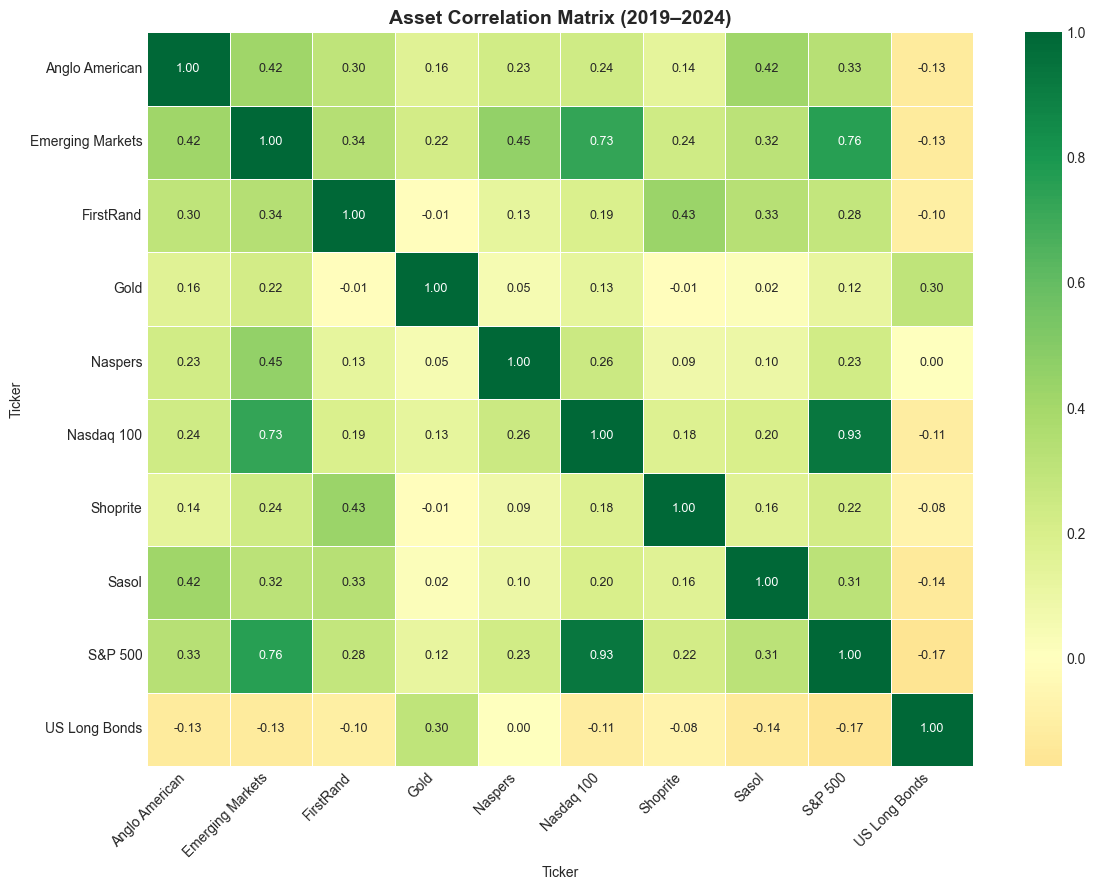

Heatmap saved ✓
Files saved:
/Users/fikilesondach/Downloads/MacroPulse_BLdata/clean_prices.csv
/Users/fikilesondach/Downloads/MacroPulse_BLdata/daily_returns.csv
/Users/fikilesondach/Downloads/MacroPulse_BLdata/cov_matrix_lw.csv

Step 1 Complete ✓


In [11]:
# ── Standard data tools ──────────────────────────────────────────────
import pandas as pd          # For handling tables of data (DataFrames)
import numpy as np           # For mathematical operations on arrays

# ── Data collection ──────────────────────────────────────────────────
import yfinance as yf        # Pulls stock price data from Yahoo Finance

# ── Visualisation ────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Makes matplotlib charts look professional

# ── Portfolio math ───────────────────────────────────────────────────
from pypfopt import risk_models   # Contains Ledoit-Wolf and covariance tools
from pypfopt import expected_returns  # Will be used later for return estimation

# ── Display settings ─────────────────────────────────────────────────
pd.set_option('display.float_format', lambda x: f'{x:.4f}')  # 4 decimal places
plt.style.use('seaborn-v0_8-darkgrid')  # Clean chart style

BASE_DIR = "/Users/fikilesondach/Downloads/MacroPulse_BL"

# ── Asset tickers ─────────────────────────────────────────────────────
tickers = [
    "NPN.JO",   # Naspers         — SA tech/consumer giant
    "FSR.JO",   # FirstRand       — SA financial services
    "AGL.JO",   # Anglo American  — SA mining/resources
    "SOL.JO",   # Sasol           — SA energy and chemicals
    "SHP.JO",   # Shoprite        — SA consumer staples
    "SPY",      # S&P 500 ETF     — US large cap equities
    "QQQ",      # Nasdaq 100 ETF  — Global technology
    "EEM",      # Emerging Mkts   — EM diversification
    "GLD",      # Gold ETF        — Commodity / inflation hedge
    "TLT",      # US Long Bonds   — Fixed income / risk-off asset
]

# ── Human-readable names for charts ───────────────────────────────────
asset_names = {
    "NPN.JO": "Naspers",
    "FSR.JO": "FirstRand",
    "AGL.JO": "Anglo American",
    "SOL.JO": "Sasol",
    "SHP.JO": "Shoprite",
    "SPY":    "S&P 500",
    "QQQ":    "Nasdaq 100",
    "EEM":    "Emerging Markets",
    "GLD":    "Gold",
    "TLT":    "US Long Bonds",
}

print(f"Asset universe: {len(tickers)} assets defined ✓")

# ── Date range ────────────────────────────────────────────────────────
START_DATE = "2019-01-01"
END_DATE   = "2024-12-31"

print(f"Downloading data from {START_DATE} to {END_DATE}...")

# ── Download ──────────────────────────────────────────────────────────
# yf.download fetches data for ALL tickers in one API call
# ["Close"] selects only the closing price column (we don't need Open/High/Low yet)
raw_prices = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]

print(f"\nDownload complete.")
print(f"Shape: {raw_prices.shape[0]} trading days × {raw_prices.shape[1]} assets")
print(f"\nFirst 5 rows:")
raw_prices.head()

# ── Check for missing values BEFORE cleaning ──────────────────────────
print("Missing values per asset (raw):")
print(raw_prices.isnull().sum())
print(f"\nTotal missing cells: {raw_prices.isnull().sum().sum()}")

# ── Forward-fill missing values ───────────────────────────────────────
# Forward-fill means: if Monday's price is missing, use Friday's price.
# This is the standard financial industry approach for non-trading days.
# It does NOT invent data — it carries the last known price forward.
prices = raw_prices.ffill()

# ── Drop any remaining rows where ALL assets are missing ──────────────
# (This handles the very first row if it starts with NaNs)
prices = prices.dropna(how='all')

# ── Verify ────────────────────────────────────────────────────────────
print("Missing values per asset (after cleaning):")
print(prices.isnull().sum())
print(f"\nClean dataset: {prices.shape[0]} trading days × {prices.shape[1]} assets")

# ── Compute daily percentage returns ──────────────────────────────────
# .pct_change() applies the return formula to every column automatically
# dropna() removes the first row which will be NaN (no previous price to compare)
daily_returns = prices.pct_change().dropna()

print(f"Daily returns shape: {daily_returns.shape}")
print(f"\nSample statistics:")
print(daily_returns.describe().round(4))

# ── Cumulative return = how R1 invested grew over time ────────────────
# (1 + daily_return).cumprod() compounds each daily return forward
cumulative_returns = (1 + daily_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))

for ticker in tickers:
    label = asset_names[ticker]
    ax.plot(cumulative_returns.index, cumulative_returns[ticker], label=label, linewidth=1.5)

ax.set_title("Cumulative Growth of R1 Invested (2019–2024)", fontsize=15, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (R1 = 1.0 at start)")
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)  # Break-even line
plt.tight_layout()
plt.savefig(BASE_DIR + "/outputs/01_cumulative_returns.png", dpi=150)
plt.show()
print("Chart saved ✓")

# ── Standard historical covariance matrix ─────────────────────────────
# .cov() computes the covariance between every pair of columns
# We multiply by 252 to annualise it (252 = average trading days per year)
cov_matrix_standard = daily_returns.cov() * 252

print("Standard Covariance Matrix (annualised):")
print(cov_matrix_standard.round(4))

# ── Ledoit-Wolf Shrinkage Covariance Matrix ───────────────────────────
# PyPortfolioOpt wraps the sklearn Ledoit-Wolf estimator
# It takes RAW PRICES (not returns) — it computes returns internally
cov_matrix_lw = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

print("Ledoit-Wolf Shrinkage Covariance Matrix (annualised):")
print(pd.DataFrame(cov_matrix_lw, 
                   index=tickers, 
                   columns=tickers).round(4))

# ── Convert covariance → correlation for readability ──────────────────
# Correlation is just a normalised covariance (values between -1 and +1)
# -1 = perfectly inverse, 0 = no relationship, +1 = move in lockstep
corr_matrix = daily_returns.corr()

# Rename tickers to full names for the chart
corr_named = corr_matrix.rename(index=asset_names, columns=asset_names)

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_named,
    annot=True,          # Show the number inside each cell
    fmt=".2f",           # 2 decimal places
    cmap="RdYlGn",       # Red = negative, Yellow = neutral, Green = positive
    center=0,            # Centre the colour scale at 0
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title("Asset Correlation Matrix (2019–2024)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_DIR + "/outputs/01_correlation_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved ✓")

# ── Save to CSV so Step 2 can load it directly ────────────────────────
prices.to_csv(BASE_DIR+"/data/clean_prices.csv")
daily_returns.to_csv(BASE_DIR+"/data/daily_returns.csv")

# Save the Ledoit-Wolf matrix as a CSV too
pd.DataFrame(cov_matrix_lw, index=tickers, columns=tickers).to_csv(BASE_DIR+"/data/cov_matrix_lw.csv")

print("Files saved:")
print(BASE_DIR+"data/clean_prices.csv")
print(BASE_DIR+"data/daily_returns.csv")
print(BASE_DIR+"data/cov_matrix_lw.csv")
print("\nStep 1 Complete ✓")
